# 1.Wprowadzenie

**Energia** odgrywa fundamentalną rolę we współczesnych społeczeństwach, wpływając na **rozwój gospodarczy**, **wzrost przemysłu** oraz **jakość życia**. Jednocześnie rosnące zapotrzebowanie na energię i coraz większa świadomość zmian klimatu przyspieszyły globalną transformację od **paliw kopalnych** do **odnawialnych źródeł energii**.

Zbiór danych analizowany w tym projekcie opiera się na bazie **World Energy Consumption** utrzymywanej przez *Our World in Data* i udostępnianej przez **Kaggle**. Zawiera on roczne obserwacje dla krajów i regionów z całego świata, obejmujące szeroki zakres wskaźników związanych z:

- zużyciem energii,
- produkcją energii elektrycznej,
- paliwami kopalnymi,
- odnawialnymi źródłami energii,
- emisjami i rozwojem gospodarczym.

> W projekcie przyjmuję podejście **przekrojowe**: jednostką analizy jest kraj w jednym wybranym roku (`rok_przekrojowy = 2020`).

**Główna zmienna analizowana (zależna):** zużycie energii na osobę (`energia_na_osobe`).

**Pytania badawcze:**

1. Jak bardzo różni się poziom zużycia energii na osobę między krajami w tym samym roku?
2. Czy kraje o wyższym PKB charakteryzują się innym poziomem zużycia energii na osobę?
3. Jak wygląda struktura miksu energetycznego (węgiel, ropa, gaz, OZE) w przekroju krajów?
4. Czy występuje związek między profilem gospodarczym kraju (grupy PKB) a standardem miksu energetycznego?

Analiza rozpoczyna się od **czyszczenia i przygotowania danych**, a następnie wykorzystuje **wizualizacje** i **analizę opisową** do odpowiedzi na pytania badawcze. Końcowa część projektu zawiera syntetyczne wnioski oraz ograniczenia analizy.

# 2.Czyszczenie i porządkowanie danych

## 2.1 Przegląd danych i identyfikacja braków

In [278]:
# Import necessary libraries
import pandas as pd
import missingno as msno
import seaborn as sns
import matplotlib.pyplot as plt
from tabulate import tabulate
import plotly.express as px
import scipy.stats as stats

In [279]:
# Loading the dataset
data = pd.read_csv('../data/raw/owid-energy-data.csv')

In [280]:
# Displaying basic information about the dataset
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 23195 entries, 0 to 23194
Columns: 130 entries, country to wind_share_energy
dtypes: float64(127), int64(1), str(2)
memory usage: 23.3 MB


In [281]:
# Checking for missing values in the dataset
data.isna().sum()

country                       0
year                          0
iso_code                   6096
population                 4466
gdp                       11415
                          ...  
wind_elec_per_capita      14894
wind_electricity          13324
wind_energy_per_capita    18050
wind_share_elec           15327
wind_share_energy         16816
Length: 130, dtype: int64

In [282]:
# Displaying basic statistics of the dataset
data.describe()

,year,population,gdp,biofuel_cons_change_pct,biofuel_cons_change_twh,biofuel_cons_per_capita,biofuel_consumption,biofuel_elec_per_capita,biofuel_electricity,biofuel_share_elec,...,solar_share_elec,solar_share_energy,wind_cons_change_pct,wind_cons_change_twh,wind_consumption,wind_elec_per_capita,wind_electricity,wind_energy_per_capita,wind_share_elec,wind_share_energy
count,23195.000000,1.872900e+04,1.178000e+04,2070.000000,7903.000000,6338.000000,8057.000000,5753.000000,6063.000000,6040.000000,...,7940.000000,6379.000000,2798.000000,6293.000000,6405.000000,8301.000000,9871.000000,5145.000000,7868.000000,6379.000000
mean,1975.859280,1.010849e+08,4.257565e+11,43.478804,1.054261,55.157858,15.092054,69.409590,12.252558,1.939152,...,0.902081,0.219802,290.408294,6.021235,48.691257,63.651510,18.589892,214.960358,1.521953,0.518141
std,35.207901,4.606079e+08,3.507870e+12,286.672317,6.641947,180.665240,75.942529,199.403432,52.276644,5.339924,...,2.775481,0.766125,6070.498582,34.260028,281.755752,259.959746,114.342308,733.884486,4.619313,1.722172
min,1900.000000,1.733000e+03,1.642060e+08,-100.000000,-59.084000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,-100.000000,-46.535000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1949.000000,1.596265e+06,1.426394e+10,-0.968000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,2.329000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1985.000000,6.875000e+06,4.357680e+10,6.695500,0.000000,0.000000,0.000000,0.793000,0.020000,0.148500,...,0.000000,0.000000,18.349500,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,2005.000000,2.531192e+07,1.830576e+11,23.320750,0.000000,0.506750,0.062000,42.905000,0.860000,1.601000,...,0.200000,0.006000,45.210750,0.096000,0.916000,1.695000,0.090000,25.914000,0.473250,0.074500
max,2024.000000,8.161972e+09,1.301126e+14,6373.062000,144.290000,2587.921000,1366.878000,2450.813000,712.160000,77.586000,...,50.000000,9.881000,242384.859000,642.617000,6124.465000,3850.312000,2497.250000,9315.340000,57.913000,26.085000


In [283]:
# Selecting relevant columns for analysis
cols = [
    "country", "year", "iso_code", "population", "gdp",
    "energy_consumption", "energy_per_capita",
    "electricity_generation", "electricity_demand",
    "coal_share_energy", "oil_share_energy", "gas_share_energy",
    "renewables_share_energy"
]
cols = [c for c in cols if c in data.columns]
data = data[cols]

data = data.rename(columns={
    "country": "kraj",
    "year": "rok",
    "iso_code": "kod_iso",
    "population": "populacja",
    "gdp": "pkb",
    "energy_consumption": "zuzycie_energii",
    "energy_per_capita": "energia_na_osobe",
    "electricity_generation": "produkcja_energii_elektrycznej",
    "electricity_demand": "zapotrzebowanie_na_energie_elektryczna",
    "coal_share_energy": "udzial_wegla_w_energii",
    "oil_share_energy": "udzial_ropy_w_energii",
    "gas_share_energy": "udzial_gazu_w_energii",
    "renewables_share_energy": "udzial_energii_odnawialnej"
})

countries = data[data["kod_iso"].notna()].copy()
countries = countries[countries["kraj"] != "ASEAN (Ember)"]
countries = countries.drop_duplicates(subset=["kraj", "rok"])

basic = countries[["kraj", "rok", "populacja", "pkb", "energia_na_osobe"]].copy()
electricity = countries[["kraj", "rok", "produkcja_energii_elektrycznej", "zapotrzebowanie_na_energie_elektryczna"]].copy()
mix = countries[["kraj", "rok", "udzial_wegla_w_energii", "udzial_ropy_w_energii", "udzial_gazu_w_energii", "udzial_energii_odnawialnej"]].copy()

In [284]:
# --- wybór jednego roku do analizy przekrojowej ---

rok_przekrojowy = 2020

basic_cs = basic[basic["rok"] == rok_przekrojowy].copy()
electricity_cs = electricity[electricity["rok"] == rok_przekrojowy].copy()
mix_cs = mix[mix["rok"] == rok_przekrojowy].copy()

print("Wybrany rok:", rok_przekrojowy)
print("basic_cs:", basic_cs.shape)
print("electricity_cs:", electricity_cs.shape)
print("mix_cs:", mix_cs.shape)

Wybrany rok: 2020
basic_cs: (220, 5)
electricity_cs: (220, 4)
mix_cs: (220, 6)


## 2.2 Analiza braków danych

### 2.2.1 Shadow mapy

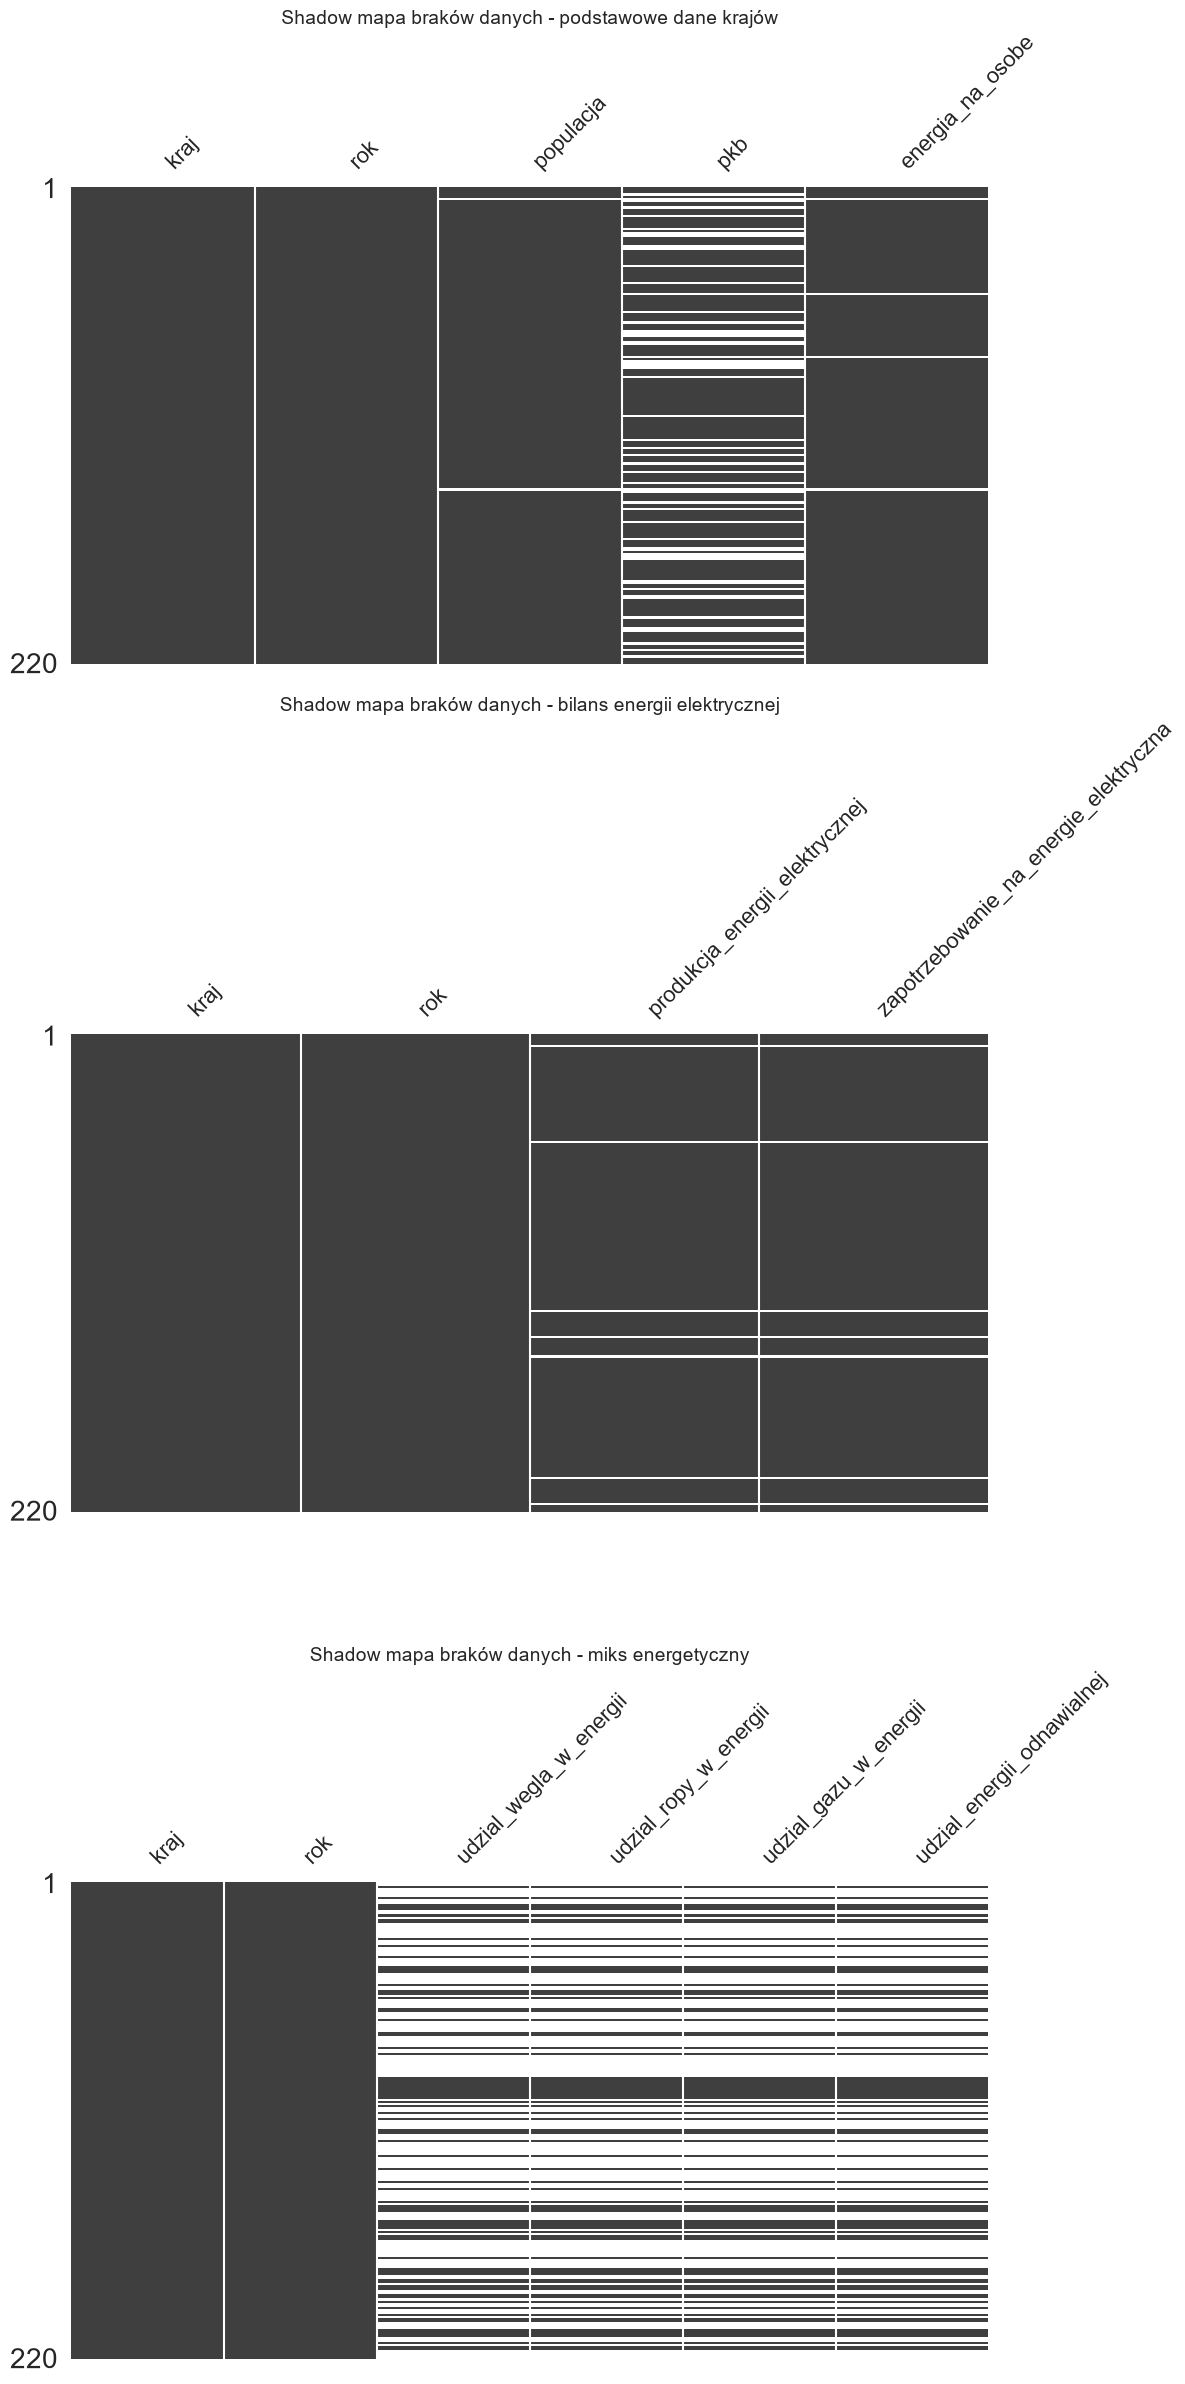

In [285]:
fig, axes = plt.subplots(3, 1, figsize=(12, 24))

msno.matrix(basic_cs, ax=axes[0], sparkline=False)
axes[0].set_title("Shadow mapa braków danych - podstawowe dane krajów")

msno.matrix(electricity_cs, ax=axes[1], sparkline=False)
axes[1].set_title("Shadow mapa braków danych - bilans energii elektrycznej")

msno.matrix(mix_cs, ax=axes[2], sparkline=False)
axes[2].set_title("Shadow mapa braków danych - miks energetyczny")

plt.tight_layout()
plt.show()

Shadow mapy przedstawiają rozmieszczenie brakujących wartości w analizowanych zbiorach danych. We wszystkich trzech zbiorach kolumny `kraj` oraz `rok` są kompletne i nie zawierają brakujących obserwacji.

W zbiorze przedstawiającym podstawowe dane krajów `basic_cs` największa liczba braków występuje w kolumnach `pkb` oraz `energia_na_osobe`. Braki te są rozproszone i nie tworzą prostego, pojedynczego wzorca.

W zbiorze przedstawiającym dane o bilansie energii elekrycznej `electricity_cs` zmienne `produkcja_energii_elektrycznej` i `zapotrzebowanie_na_energie_elektryczna` mają bardzo podobne rozmieszczenie braków, co sugeruje wspólne źródło raportowania.

W zbiorze przedstawiająxym dane o miksie energetycznym `mix_cs` braki w udziałach źródeł energii pojawiają się najczęściej równocześnie, co oznacza, że dla części krajów brakuje całego pakietu informacji o miksie energetycznym.

Podsumowanie

Analiza shadow map wskazuje, że brakujące wartości nie są rozmieszczone losowo. Zmienne należące do tej samej grupy tematycznej wykazują bardzo podobny wzorzec braków, co sugeruje ich wspólne źródło. Najiększa liczba braków dotyczy szczegółowych danych mixu energetycznego.

Strategia postępowania z brakującymi danymi

Ponieważ większość braków wynika z ograniczonej dostępności danych historycznych, zrezygnowano z imputacji brakujących wartości. Uzupełnianie ich mogłoby prowadzić do zniekształcenia wyników analizy i błędnej interpretacji trendów. W dalszej części projektu wykorzystano wyłącznie obserwacje zawierające wartości dla zmiennych niezbędnych do realizacji postawionych pytań badawczych.

### 2.2.2 Heatmapy korelacji braków

In [286]:
cross_all = (
    basic_cs
    .merge(electricity_cs, on=["kraj", "rok"], how="inner")
    .merge(mix_cs, on=["kraj", "rok"], how="inner")
)

print("Wymiary cross_all:", cross_all.shape)
cross_all.head()

Wymiary cross_all: (220, 11)


,kraj,rok,populacja,pkb,energia_na_osobe,produkcja_energii_elektrycznej,zapotrzebowanie_na_energie_elektryczna,udzial_wegla_w_energii,udzial_ropy_w_energii,udzial_gazu_w_energii,udzial_energii_odnawialnej
0,Afghanistan,2020,39068933.0,7.141771e+10,1200.743,1.18,6.33,NaN,NaN,NaN,NaN
1,Albania,2020,2871900.0,3.213073e+10,7352.949,5.31,7.59,NaN,NaN,NaN,NaN
2,Algeria,2020,44042041.0,5.598199e+11,14733.622,79.37,79.31,0.235,32.665,66.818,0.283
3,American Samoa,2020,49732.0,NaN,27671.668,0.17,0.17,NaN,NaN,NaN,NaN
4,Angola,2020,33451100.0,1.523087e+11,2281.594,16.81,16.81,NaN,NaN,NaN,NaN


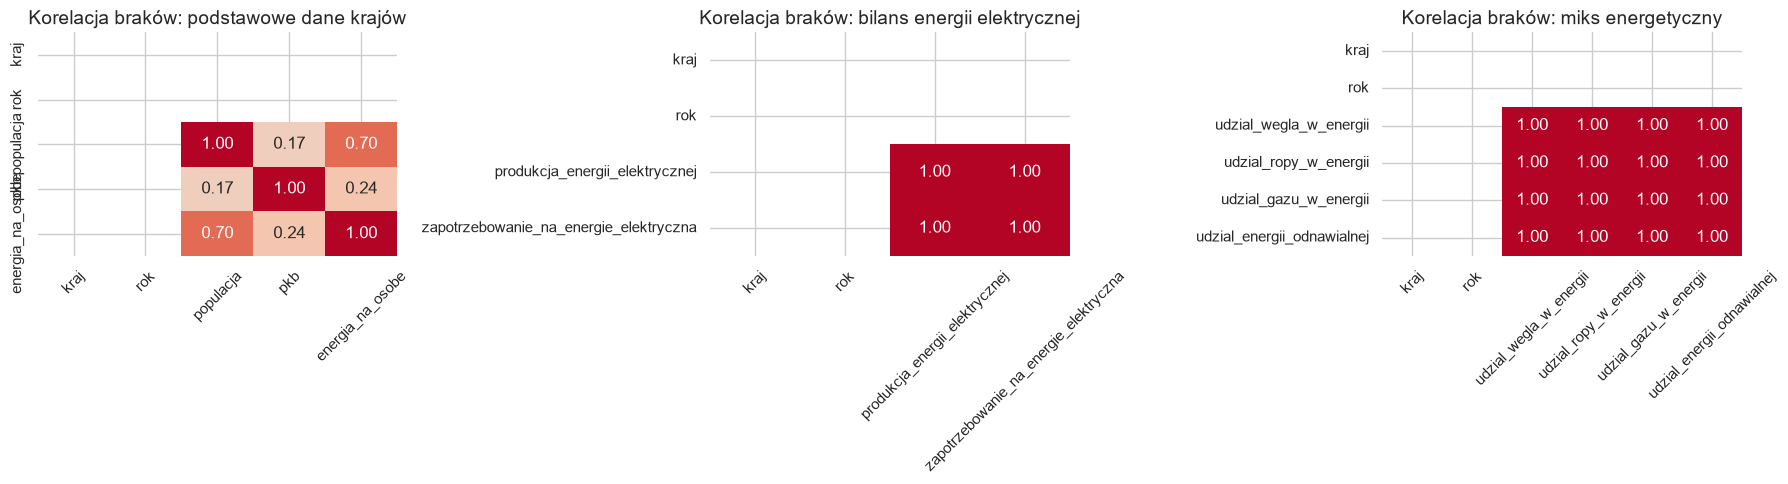

In [287]:
# Heatmapy korelacji braków danych dla zbiorów przekrojowych
datasets = {
    "podstawowe dane krajów": basic_cs,
    "bilans energii elektrycznej": electricity_cs,
    "miks energetyczny": mix_cs,
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, df_tmp) in zip(axes, datasets.items()):
    miss_corr = df_tmp.isna().corr()
    sns.heatmap(
        miss_corr,
        ax=ax,
        cmap="coolwarm",
        vmin=-1,
        vmax=1,
        annot=True,
        fmt=".2f",
        cbar=False
    )
    ax.set_title(f"Korelacja braków: {name}")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

Heatmapy przedstawiają stopień współwystępowania brakujących wartości pomiędzy analizowanymi zmiennymi. Wartości na mapach odpowiadają korelacji braków danych – im bliższa wartość 1, tym częściej braki występują jednocześnie w porównywanych zmiennych.

Heatmapa podstawowych danych krajów obejmuje zmienne: populacja, PKB oraz energia na osobę. Analiza wskazuje na stosunkowo słabą zależność pomiędzy brakami danych w tych zmiennych. Oznacza to, że brak wartości w jednej kolumnie nie musi oznaczać jednoczesnego braku danych w pozostałych zmiennych. Braki mają charakter bardziej niezależny i nie tworzą wyraźnego wspólnego wzorca.

Heatmapa danych bilansu energii elektrycznej przedstawia zależność pomiędzy zmiennymi produkcją oraz zapotrzebowaniem na energię elektryczną. Uzyskana wartość korelacji braków wynosząca 1 wskazuje na całkowitą zgodność ich występowania. Oznacza to, że brak danych dotyczących produkcji energii elektrycznej wiąże się również z brakiem informacji o zapotrzebowaniu na energię elektryczną. Sugeruje to, że obie zmienne pochodzą z tego samego źródła danych i były raportowane równocześnie.

Heatmapa danych odnośnie miksu energetycznego obejmuje zmienne opisujące udział poszczególnych źródeł energii w miksie energetycznym (udział węgla, ropy, gazu oraz energii odnawialnej). Wszystkie pary zmiennych osiągają współczynnik korelacji braków równy 1,0, co oznacza pełną zgodność wzorca brakujących danych. W praktyce oznacza to, że jeżeli dla danej obserwacji brakuje informacji o udziale jednego źródła energii, to jednocześnie brakuje danych dla wszystkich pozostałych zmiennych opisujących miks energetyczny. Świadczy to o tym, że dane dotyczące struktury miksu energetycznego były udostępniane jako kompletny zestaw informacji.

Podsumowanie

Analiza heatmap potwierdza, że brakujące wartości nie występują losowo. Zmienne należące do tej samej grupy tematycznej charakteryzują się wysoką korelacją braków danych, co wskazuje na ich wspólne źródło oraz sposób raportowania. Najsilniejszą zależność zaobserwowano dla zmiennych opisujących strukturę miksu energetycznego oraz produkcji i zapotrzebowania na energię elektryczną, gdzie współczynnik korelacji braków osiąga wartość 1,0. Wyniki te są zgodne z obserwacjami uzyskanymi na podstawie shadow map i potwierdzają, że brak danych wynika przede wszystkim z niedostępności całych zestawów informacji dla określonych krajów, a nie z przypadkowych braków pojedynczych wartości.

### 2.2.3 Dendogramy braku danych

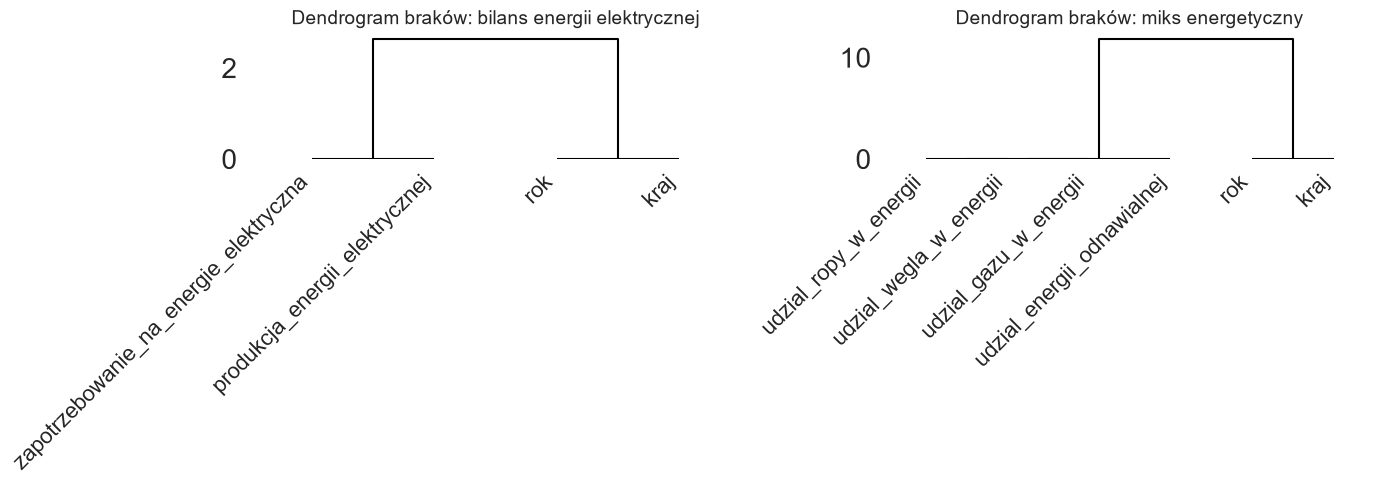

In [288]:
# Dendrogram braków danych
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

msno.dendrogram(electricity_cs, ax=axes[0], orientation="top")
axes[0].set_title("Dendrogram braków: bilans energii elektrycznej")

msno.dendrogram(mix_cs, ax=axes[1], orientation="top")
axes[1].set_title("Dendrogram braków: miks energetyczny")

plt.tight_layout()
plt.show()

Dendrogram brakujących danych przedstawia podobieństwo wzorców występowania braków pomiędzy analizowanymi zmiennymi. Zmienne połączone na niższych poziomach drzewa charakteryzują się bardziej zbliżonym rozmieszczeniem brakujących wartości, natomiast połączenia na wyższych poziomach wskazują na mniejsze podobieństwo. Analiza dendrogramów potwierdziła wyniki uzyskane na podstawie shadow map oraz heatmap. Zmienne dotyczące produkcji i zapotrzebowania na energię elektryczną tworzą wspólną grupę, co świadczy o bardzo podobnym wzorcu braków. Równie silną zależność zaobserwowano dla zmiennych opisujących strukturę miksu energetycznego, które zostały połączone w jedną zwartą gałąź, wskazując na niemal identyczne występowanie braków danych. Wyniki sugerują, że braki wynikają z jednoczesnej niedostępności całych zestawów informacji dla wybranych krajów lub lat, a nie z losowego braku pojedynczych obserwacji.

## 2.3 Strategia imputacji brakujących danych


Ponieważ większość braków wynika z ograniczonej dostępności danych historycznych, zrezygnowano z imputacji brakujących wartości. Uzupełnianie ich mogłoby prowadzić do zniekształcenia wyników analizy i błędnej interpretacji. Zdecydowano o usunięciu wierszy z brakującymi danymi dla określonych zmiennych. Tym samym, w dalszej części projektu wykorzystano wyłącznie obserwacje zawierające wartości dla zmiennych niezbędnych do realizacji postawionych pytań badawczych.

In [289]:
corr_cols = [
    "populacja",
    "pkb",
    "energia_na_osobe",
    "produkcja_energii_elektrycznej",
    "zapotrzebowanie_na_energie_elektryczna",
    "udzial_wegla_w_energii",
    "udzial_ropy_w_energii",
    "udzial_gazu_w_energii",
    "udzial_energii_odnawialnej"
]

cross_all_clean = cross_all.dropna(subset=corr_cols).copy()

print("Wymiary cross_all_clean:", cross_all_clean.shape)
cross_all_clean[corr_cols].head()

Wymiary cross_all_clean: (79, 11)


,populacja,pkb,energia_na_osobe,produkcja_energii_elektrycznej,zapotrzebowanie_na_energie_elektryczna,udzial_wegla_w_energii,udzial_ropy_w_energii,udzial_gazu_w_energii,udzial_energii_odnawialnej
2,44042041.0,5.598199e+11,14733.622,79.37,79.31,0.235,32.665,66.818,0.283
7,45191917.0,7.358142e+11,19117.844,144.64,149.35,1.167,32.910,51.208,11.833
10,25743732.0,1.232260e+12,61584.387,265.15,265.15,29.709,33.141,26.858,10.292
11,8921362.0,3.632811e+11,44852.355,69.04,71.24,7.409,33.949,21.762,36.880
12,10181688.0,1.586975e+11,18162.854,25.75,24.74,0.002,31.262,66.945,1.790


# 3. Wizualizacje (analiza przekrojowa)

W tej sekcji każda obserwacja odpowiada pojedynczemu krajowi w wybranym roku (`rok_przekrojowy`).

In [290]:
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

# Pracujemy przekrojowo: jedna obserwacja = kraj w wybranym roku
df_cs = cross_all.copy()
required_cols = [
    "kraj", "rok", "populacja", "pkb", "energia_na_osobe",
    "produkcja_energii_elektrycznej", "zapotrzebowanie_na_energie_elektryczna",
    "udzial_wegla_w_energii", "udzial_ropy_w_energii", "udzial_gazu_w_energii",
    "udzial_energii_odnawialnej"
]
df_cs = df_cs.dropna(subset=required_cols).copy()

# Zmienne pomocnicze do przekrojów
df_cs["udzial_kopalny_w_energii"] = (
    df_cs["udzial_wegla_w_energii"]
    + df_cs["udzial_ropy_w_energii"]
    + df_cs["udzial_gazu_w_energii"]
)
df_cs["pkb_na_osobe"] = df_cs["pkb"] / df_cs["populacja"]

pkb_rank = df_cs["pkb"].rank(method="first")
df_cs["grupa_pkb"] = pd.qcut(
    pkb_rank,
    q=3,
    labels=["niski PKB", "średni PKB", "wysoki PKB"]
)

df_cs["standard_miksu"] = pd.cut(
    df_cs["udzial_energii_odnawialnej"],
    bins=[-0.1, 25, 50, 100],
    labels=["niski udział OZE", "średni udział OZE", "wysoki udział OZE"]
)

print(f"Rok analizy przekrojowej: {rok_przekrojowy}")
print(f"Liczba obserwacji po czyszczeniu: {len(df_cs)}")
df_cs[["kraj", "rok", "energia_na_osobe", "grupa_pkb", "standard_miksu"]].head()

Rok analizy przekrojowej: 2020
Liczba obserwacji po czyszczeniu: 79


,kraj,rok,energia_na_osobe,grupa_pkb,standard_miksu
2,Algeria,2020,14733.622,średni PKB,niski udział OZE
7,Argentina,2020,19117.844,średni PKB,niski udział OZE
10,Australia,2020,61584.387,wysoki PKB,niski udział OZE
11,Austria,2020,44852.355,średni PKB,średni udział OZE
12,Azerbaijan,2020,18162.854,niski PKB,niski udział OZE


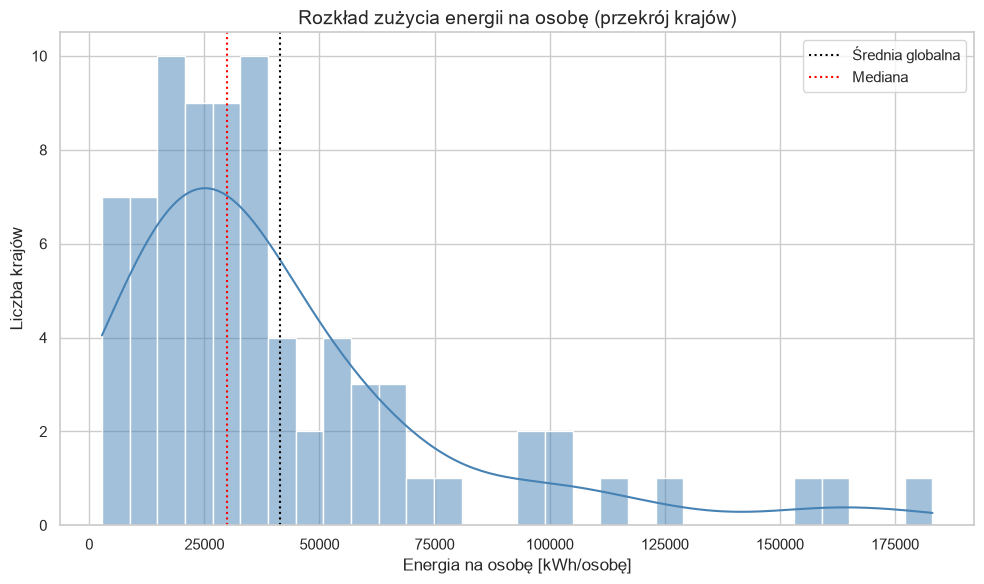

In [291]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df_cs, x="energia_na_osobe", bins=30, kde=True, color="steelblue")
plt.title("Rozkład zużycia energii na osobę (przekrój krajów)")
plt.xlabel("Energia na osobę [kWh/osobę]")
plt.ylabel("Liczba krajów")
plt.tight_layout()
plt.axvline(df_cs["energia_na_osobe"].mean(), color="black", linestyle="dotted", label="Średnia globalna")
plt.axvline(df_cs["energia_na_osobe"].median(), color="red", linestyle="dotted", label="Mediana")
plt.legend()    
plt.show()

Histogram pokazuje, że rozkład zużycia energii na osobę jest asymetryczny: większość krajów skupia się przy niższych wartościach, a niewielka grupa ma bardzo wysokie poziomy.
Sugeruje to silne zróżnicowanie energetyczne pomiędzy krajami.

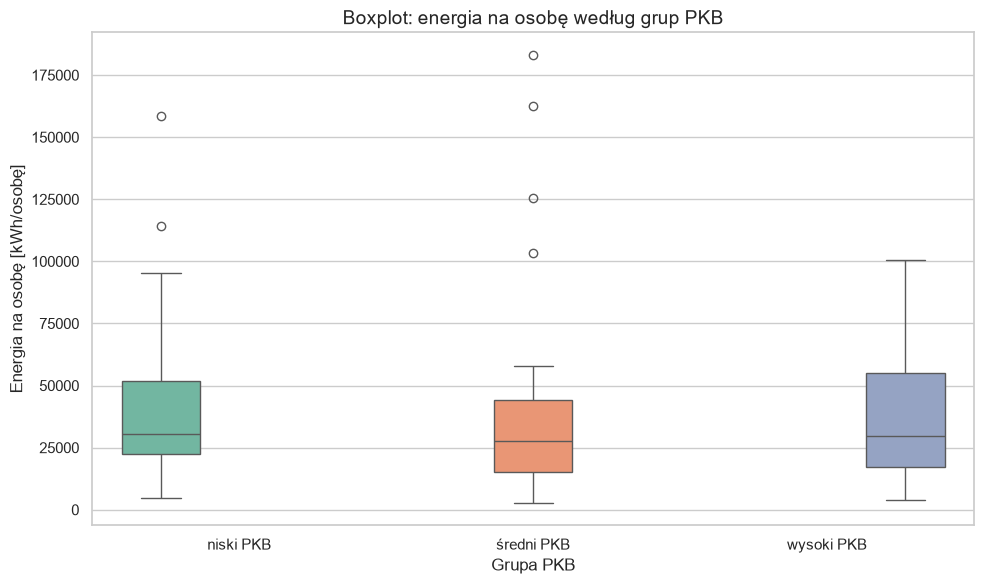

In [292]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_cs,
    x="grupa_pkb",
    y="energia_na_osobe",
    hue="grupa_pkb",
    palette="Set2",
    legend=False,
    )
plt.title("Boxplot: energia na osobę według grup PKB")
plt.xlabel("Grupa PKB")
plt.ylabel("Energia na osobę [kWh/osobę]")
plt.tight_layout()
plt.show()

In [293]:
fig=px.strip(df_cs, x="energia_na_osobe", hover_data=["kraj"], color="grupa_pkb", color_discrete_map={
        "niski PKB": "green",
        "średni PKB": "orange",
        "wysoki PKB": "blue"
    }) 
fig.update_layout(
    title="Rozkład zużycia energii na osobę względem grup PKB",
    xaxis_title="Energia na osobę [kWh/osobę]",
    yaxis_title="Grupa PKB",
    title_x=0.5,
    )
fig.show()   


Boxplot przedstawia zużycie energii na osobę w zależności od przynależności do grupy PKB. Obserwowana duża rozpiętość pudełek i obecność obserwacji odstających pokazują, że zależność nie jest całkowicie jednorodna.
Wysokość pudełka wyznaczana jest pomiędzy pierwszym kwartylem (25%) a trzecim kwartylem (75%). Linie nad i pod obrazują zakres typowych danych poza rozstępem międzykwartylowym. 
Można zaobserwować, że wartość mediany dla wszystkich grup jest podobna. Natomiast wartość trzeciego kwartylu dla krajów o wysokim PKB znacząco przewyższa jego wartość dla krajów o średnim PKB, a także znacznie większy jest zakres górny typowych wartości poza rozstępem międzykwatylnym. Mniejsze zakresy typowych wartości poza rozstępem międzykwartylowym dla grupy o średnim PKB wskazują, że większość krajów w tej grupie ma podobny poziom wartości energii na osobę. Jednakże jednocześnie największa liczba obserwacji odstających została zaobserwowana właśnie dla grupy krajów o średnim poziomie PKB, wyróżniając kraje o przewyższająco wysokim zużyciu energii na mieszkańca: Norwegia, Zdjenoczone Emiraty Arabskie, Singapur, Katar. Dla krajów o niskim PKB również widnieją obserwacje odstające. Obserwacje wskazują, że wysoki poziom zużycia energii na osobę nie jest jedynie cechą charakteryzującą wyłącznie kraje wysoko rozwinięte, a mają wpływ inne czynniki.
Rozkład rozbieżności z możliwością identyfikacji krajów w badanym aspeckie obrazuje wykres punktowy rozkładu zużycia energii na osobę względem grup PKB.

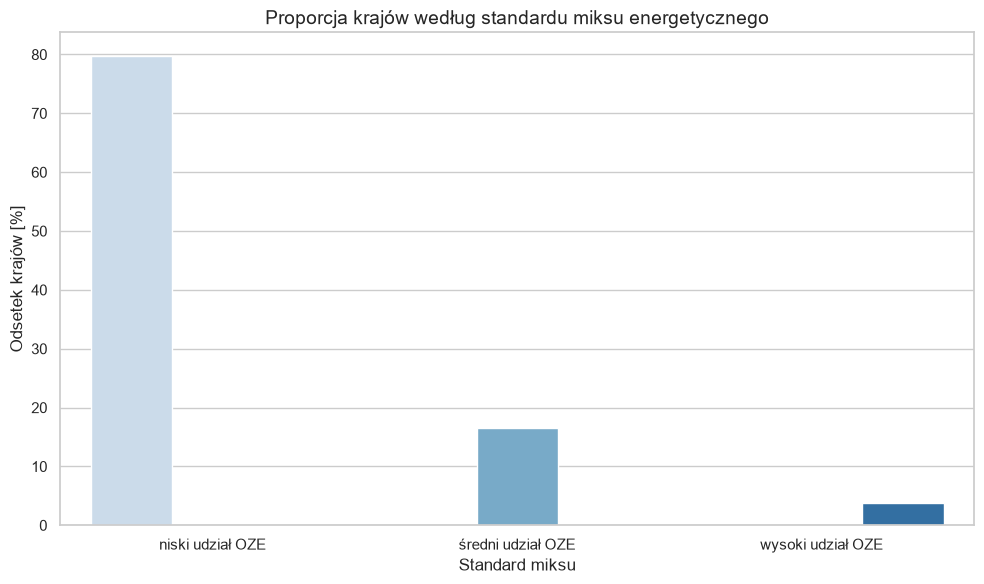

In [294]:
standard_share = (
    df_cs["standard_miksu"]
    .value_counts(normalize=True)
    .mul(100)
    .rename_axis("standard_miksu")
    .reset_index(name="procent_krajow")
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=standard_share,
    x="standard_miksu",
    y="procent_krajow",
    hue="standard_miksu",
    palette="Blues",
    legend=False
)
plt.title("Proporcja krajów według standardu miksu energetycznego")
plt.xlabel("Standard miksu")
plt.ylabel("Odsetek krajów [%]")
plt.tight_layout()
plt.show()

Wykres słupkowy przedstawia proporcję krajów według standardu miksu energetycznego (niski, średni i wysoki udział OZE).
Dzięki temu łatwo ocenić, jaki odsetek krajów znajduje się już w bardziej „zielonym” modelu energetycznym.

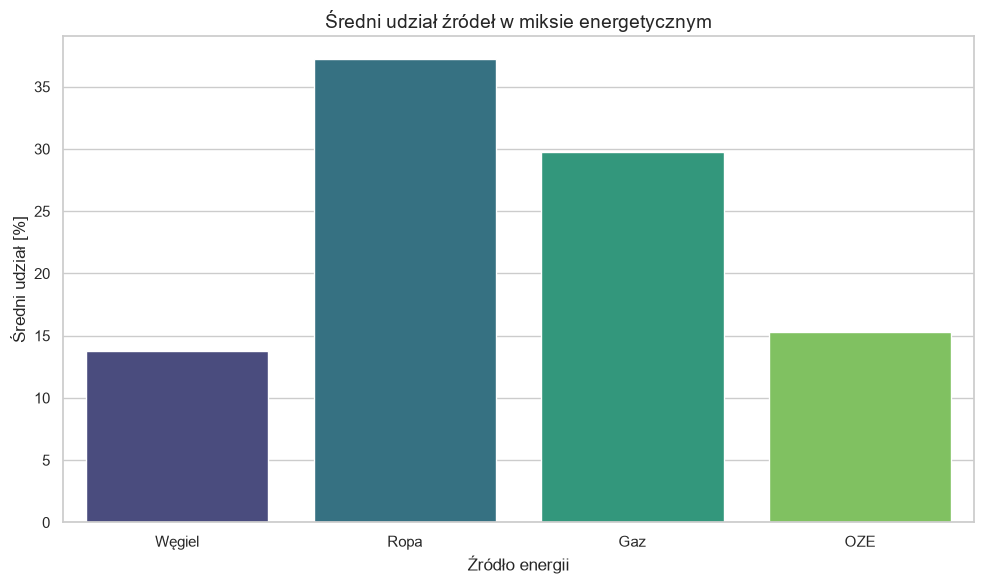

In [295]:
mix_mean = (
    df_cs[[
        "udzial_wegla_w_energii",
        "udzial_ropy_w_energii",
        "udzial_gazu_w_energii",
        "udzial_energii_odnawialnej"
    ]]
    .mean()
    .reset_index()
    .rename(columns={"index": "zrodlo", 0: "sredni_udzial"})
)

etykiety = {
    "udzial_wegla_w_energii": "Węgiel",
    "udzial_ropy_w_energii": "Ropa",
    "udzial_gazu_w_energii": "Gaz",
    "udzial_energii_odnawialnej": "OZE"
}
mix_mean["zrodlo"] = mix_mean["zrodlo"].map(etykiety)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=mix_mean,
    x="zrodlo",
    y="sredni_udzial",
    hue="zrodlo",
    palette="viridis",
    legend=False
)
plt.title("Średni udział źródeł w miksie energetycznym")
plt.xlabel("Źródło energii")
plt.ylabel("Średni udział [%]")
plt.tight_layout()
plt.show()

Średnie udziały źródeł energii pokazują dominujące elementy miksu w analizowanym przekroju krajów.
Porównanie słupków pozwala szybko ocenić relatywną rolę paliw kopalnych i OZE. Wykres wskazuje na znaczący udział wykorzystania ropy naftowej, która wraz z gazem pozostają głównymi nośnikami energii w badanych krajach. Średnie udziały źródeł eneregii wskazują na rosnącą rolę odnawialnych źródeł energii (OZE), który przewyższa udział węgla, co świadczy o postępującej transformacji energetycznej poprzez stopniowe ograniczanie znaczenia paliw kopalnych w światowej produkcji energii.

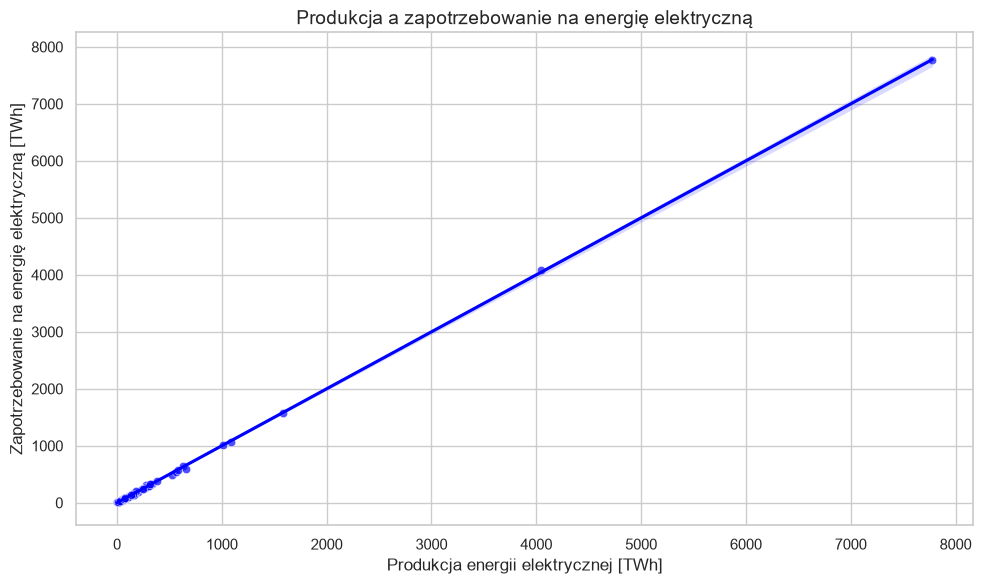

Współczynniki kierunkowe regresji liniowej (a) dla poszczególnych grup PKB:
średni PKB: a = 0.957
wysoki PKB: a = 1.000
niski PKB: a = 1.017


In [296]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_cs,
    x="produkcja_energii_elektrycznej",
    y="zapotrzebowanie_na_energie_elektryczna",
    alpha=0.7,
    color="blue"
    )
sns.regplot(data=df_cs, x="produkcja_energii_elektrycznej", y="zapotrzebowanie_na_energie_elektryczna", scatter=False, color="blue")
plt.title("Produkcja a zapotrzebowanie na energię elektryczną")
plt.xlabel("Produkcja energii elektrycznej [TWh]")
plt.ylabel("Zapotrzebowanie na energię elektryczną [TWh]")
plt.tight_layout()
plt.show()
fig=px.scatter(
    data_frame=df_cs,
    x="produkcja_energii_elektrycznej",
    y="zapotrzebowanie_na_energie_elektryczna",
    hover_data=["kraj"],
    color="grupa_pkb",
    size="populacja",
    size_max=15,
    opacity=0.7,
    trendline="ols",
    facet_row="grupa_pkb",
    color_discrete_map={
        "niski PKB": "green",
        "średni PKB": "orange",
        "wysoki PKB": "blue" }
    )
fig.update_layout(
    title="Produkcja a zapotrzebowanie na energię elektryczną",
    xaxis_title="Produkcja energii elektrycznej [TWh]",
    width=1000,
    title_x=0.5,
    showlegend=False     
)
fig.update_xaxes(
    matches=None,
    autorange=True,
    showticklabels=True
    )
fig.update_yaxes(matches=None)
fig.update_yaxes(title_text="",row=1)
fig.update_yaxes(title_text="Zapotrzebowanie na energię elektryczną [TWh]",row=2)
fig.update_yaxes(title_text="",row=3)
for annotation in fig.layout.annotations:
    annotation.text = annotation.text.split("=")[-1]

fig.show()  
 # wyniki regresji
results = px.get_trendline_results(fig)
print("Współczynniki kierunkowe regresji liniowej (a) dla poszczególnych grup PKB:")
for i, row in results.iterrows():
    model = row["px_fit_results"]
    a = model.params[1]   # współczynnik kierunkowy

    print(f"{row['grupa_pkb']}: a = {a:.3f}")  

      


Wykres punktowy wskazuje na dodatnią zależność między produkcją i zapotrzebowaniem na energię elektryczną. Oznacza to, że wzrost produkcji elektrycznej jest związany ze wzrostem zapotrzebownaia na energię. 
Potwierdza dodatni współcznikk kierunkowy linii trendu uzyskany we wszystkich analizowanych grupach PKB.  Dla krajów o niskim PKB, wspóczynnik kierunkowy trendu powyżej wartości 1, świadczy na szybki wzrost zapotrzebowania, co może być związane z dynamicznym rozwojem gospodarczym i zwiększania dostępy do energii. Dla krajów o średnim PKB, współczynnik kierunkowy poniżej wartości 1 świadczy o szybszym wzroście produkcji energii w stosunku do tempa wzrostu zapotrzebowania na energię, co sugerować może na zwiększenie nadwyżek energetycznych poprzez poprawę infrastruktury energetycznej oraz potencjalne możliwości eksportu energii. Dla krajów o wysokim PKB, zależność jest proporcjonalna, co stanoiw o stabilności relacji pomiędzy podażą a popytem w krajach o wysoko rozwiniętym systemie energetycznym.


# 4. Analiza opisowa

## Statystki opisowe ogólne

--- Statystyki opisowe (ogółem) ---
|                            |   count |     mean |      std |     min |      25% |      50% |      75% |       max |   skośność |   kurtoza |
|----------------------------|---------|----------|----------|---------|----------|----------|----------|-----------|------------|-----------|
| energia_na_osobe           |      79 | 41367    | 36749.4  | 2750.77 | 18805.5  | 29845.6  | 54826.1  | 183126    |       1.96 |      4.13 |
| pkb_na_osobe               |      79 | 29597.2  | 20621    | 4536.18 | 14308.2  | 25333.9  | 39115    | 128603    |       1.85 |      5.98 |
| udzial_energii_odnawialnej |      79 |    15.34 |    15.88 |    0.01 |     4.02 |    10.64 |    20.42 |     86.13 |       2    |      5.5  |


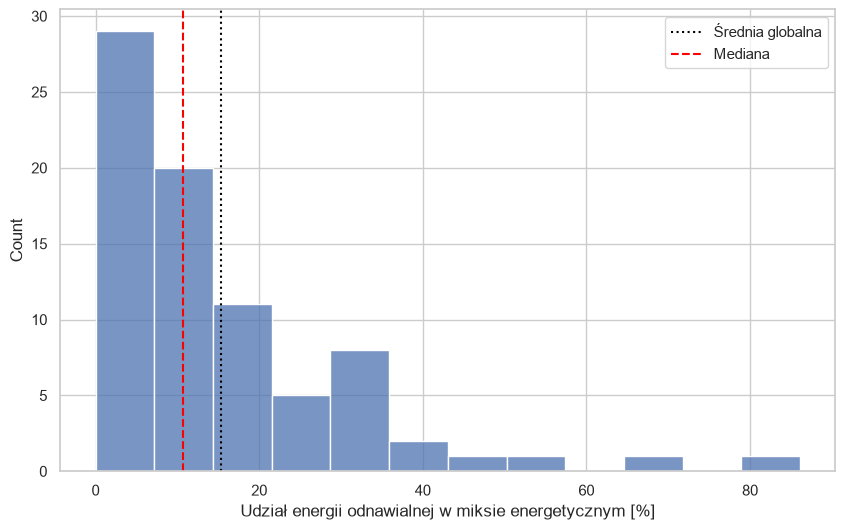


--- Energia na osobę wg grup PKB ---
| grupa_pkb   |   count |    mean |     std |     min |     25% |     50% |     75% |    max |   skośność |   kurtoza |
|-------------|---------|---------|---------|---------|---------|---------|---------|--------|------------|-----------|
| niski PKB   |      27 | 42930.1 | 34687.9 | 4653.04 | 22414.5 | 30643.5 | 51988.9 | 158445 |       1.81 |      3.06 |
| średni PKB  |      26 | 43962.3 | 47337.1 | 2750.77 | 15068.4 | 27755.3 | 44126.6 | 183126 |       1.82 |      2.31 |
| wysoki PKB  |      26 | 37148.4 | 26330.5 | 4083.67 | 17115.8 | 29844.9 | 54999.4 | 100465 |       0.78 |     -0.06 |


In [299]:
# Analiza 1: statystyki opisowe energii na osobę ogółem i wg grup PKB
#ogółem
desc_global = df_cs[["energia_na_osobe", "pkb_na_osobe", "udzial_energii_odnawialnej"]].describe().T
desc_global["skośność"] = df_cs[["energia_na_osobe", "pkb_na_osobe", "udzial_energii_odnawialnej"]].skew().round(2)
desc_global["kurtoza"] = df_cs[["energia_na_osobe", "pkb_na_osobe", "udzial_energii_odnawialnej"]].kurtosis().round(2) 
#wykres dla udziału energii odnawialnej w miksie energetycznym       
sns.histplot(data=df_cs, x="udzial_energii_odnawialnej")
plt.axvline(df_cs["udzial_energii_odnawialnej"].mean(), color="black", linestyle="dotted", label="Średnia globalna")
plt.axvline(df_cs["udzial_energii_odnawialnej"].median(), color="red", linestyle="dashed", label="Mediana")
plt.xlabel("Udział energii odnawialnej w miksie energetycznym [%]")
plt.legend()
#według PKB
desc_group = (
    df_cs.groupby("grupa_pkb", observed=False)["energia_na_osobe"]
    .describe()
    .round(2)
    )
desc_group["skośność"]=(
    df_cs.groupby("grupa_pkb", observed=False)["energia_na_osobe"]
    .apply(stats.skew)
    .round(2)
)
desc_group["kurtoza"]=(
    df_cs.groupby("grupa_pkb", observed=False)["energia_na_osobe"]
    .apply(stats.kurtosis)
    .round(2)
)


print("--- Statystyki opisowe (ogółem) ---")
print(tabulate(desc_global.round(2), headers="keys", tablefmt="github"))

plt.show()
print("\n--- Energia na osobę wg grup PKB ---")
print(tabulate(desc_group, headers="keys", tablefmt="github"))


Statystyki opisowe potwierdzają duże zróżnicowanie zużycia energii na osobę między krajami. 

Średnie zużycie energii na osobę wynosi około 41.4 tysiące kWh/osobę przy dużym odchyleniu standardowym 36.7 tysięcy, co odzwierciedla dużą zmienność pomiędzy analizowanymi krajami. 
Mediana jest niższa od średniej, co wskazuje na prawostroną asymetrię rozkładu, odzwierciedlaną przez dodatnią wartość skośności.

Zmienna PKB na mieszkańca również charakteryzuje się prawostronną asymetrią oraz wysoką kurtozą. Oznacza to, że większość krajów znajduje się w zakresie umiarkownacyh wartości PKB na mieszkańca, jednakże niewielka grupa bardzo bogatych państw znacząco odbiega od pozostałych.

Rozkład udziału energii odnawialnej charakteryzuje się największą asymetrią (skośność 2.0), a jednocześnie wysoką kurtozą. Wskazuje to co na występowaniu kilku krajów o wyjątkowo wysokim udziale OZE,w porównaniu do większości państw o znacznie niższym udziale tego źródła energii w miskie energetycznym. Świadczy to o bardzo różnych modelach energetycznych państw i nierównomiernym przebiegu transformacji energetycznej. Przypadek ten został zobrazowany na wykresie.

Wyniki pokazują, że poziom PKB nie determinuje jednoznacznie zużycia energii na osobę. W przeprowadzonej analizie na badanych krajach najwyższe średnie zużycie energii na osobę odnotowano w grupie krajów o średnim PKB. Najwyższe odchylenie standardowe oznaczające największe różnice zużycia energii zostało zaobserwowane w grupie średniego poziomu PKB, gdzie występują zarówno kraje o umiarkowanym zużyciu energii, jak i państwa o bardzo wysokiej energochłonności. Wskazuje to, że oprócz poziomu gospodarczego istotny wpływ mają również inne parametry, takie jak struktura przemysłu, dostępność zasobów energetycznych oraz model energetyczny kraju. Dodatnia skośność we wszystkich grupach oznacza, że rozkłady są prawostronnie asymetryczne, poprzez występowanie pojedynczych krajów o znacznie wyższym zużyciu energii na osobę niż w większości obserwacji. Najmniejsza wartość skosności oraz kurtozy występuje dla grupy krajów o wysokim PKB, wskazując na najbardziej symetryczny i stabilny rozkład pośród krajów należących do tej grupy. Natomiast wyższe wartości skośności i kurtozy w grupach o niskim i średnim poziomie PKB świadczą o większym wpływie obserwacji odstających na całkowity rozkład zużycia energii.
Kwartyle przedstawiają rozkład zużycia energii na osobę w poszczególnych grupach PKB. Pierwszy kwartyl (25%) oznacza wartość, poniżej której znajduje się 25% krajów danej grupy, mediana (50%) dzieli obserwacje na dwie równe części, natomiast trzeci kwartyl (75%) wyznacza wartość, poniżej której znajduje się 75% krajów. Mediany wszystkich trzech grup są dość zbliżone, natomiast wartości średnich różnią się już znacząco.  Porównanie trzeciego kwartylu wskazuje, że typowo wysokie wartości zużycia energii są najwyższe w grupie krajów o wysokim PKB, a wysoka średnia w grupie krajów o średnim PKB wynika przede wszystkim z obecności pojedynczych obserwacji odstających. Oznacza to że istotny wpływ na wartość średniej pojedynczych krajów o bardzo wysokim zużyciu energii, które to kraje zawyżają średnią.

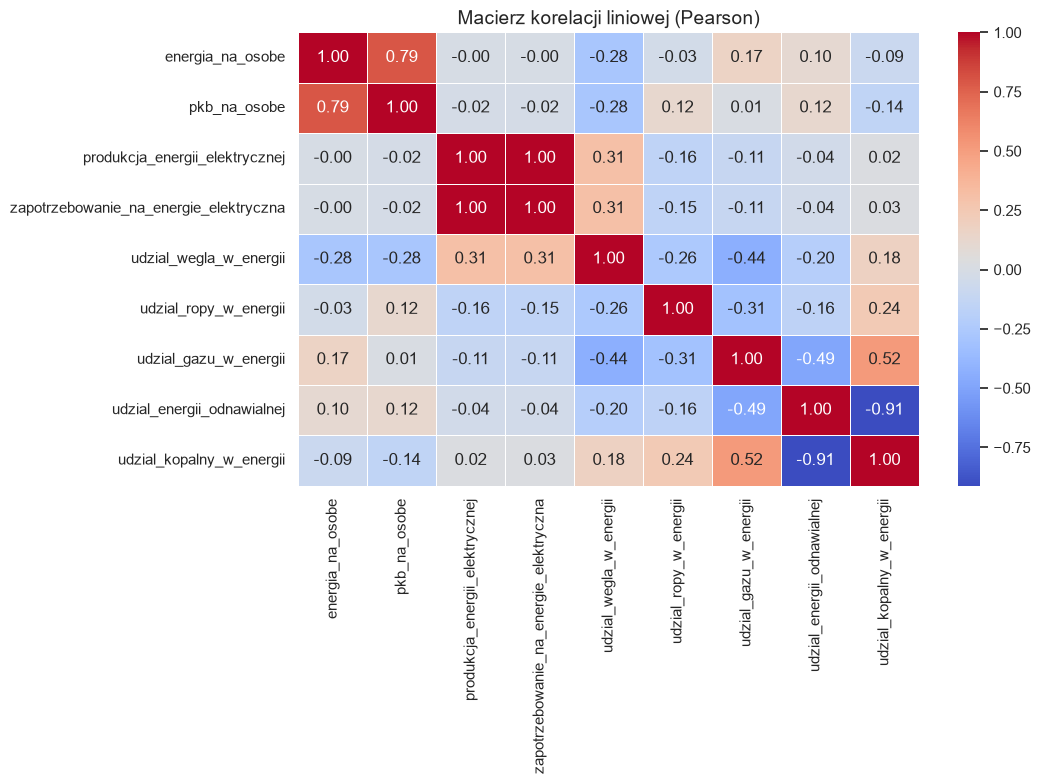

In [298]:
# Analiza 2: korelacja liniowa (Pearson)
corr_cols = [
    "energia_na_osobe",
    "pkb_na_osobe",
    "produkcja_energii_elektrycznej",
    "zapotrzebowanie_na_energie_elektryczna",
    "udzial_wegla_w_energii",
    "udzial_ropy_w_energii",
    "udzial_gazu_w_energii",
    "udzial_energii_odnawialnej",
    "udzial_kopalny_w_energii"
]

corr_pearson = df_cs[corr_cols].corr(method="pearson")

plt.figure(figsize=(11, 8))
sns.heatmap(corr_pearson, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Macierz korelacji liniowej (Pearson)")
plt.tight_layout()
plt.show()

Macierz Pearsona pokazuje, że najsilniejsze zależności liniowe dotyczą par zmiennych technicznie powiązanych (np. produkcja i zapotrzebowanie energii elektrycznej).
W przypadku relacji między energią na osobę, poziomem PKB i udziałami źródeł energii zależności są zróżnicowane... 

# 5. Wnioski końcowe

1. Po dostosowaniu danych do analizy przekrojowej możliwe było porównanie krajów w jednym roku i wskazanie dużego zróżnicowania poziomu konsumpcji energii oraz struktury miksu energetycznego.
2. Energia na osobę różni się między grupami PKB, ale obserwowany układ nie jest idealnie liniowy ani monotoniczny, co wskazuje na znaczenie dodatkowych uwarunkowań.
3. Udział OZE istotnie różnicuje kraje w przekroju, jednak w wielu obserwacjach paliwa kopalne nadal stanowią dominującą część miksu energetycznego.
4. Wnioski do analizy opisowej ... 
5. Ograniczenia: analiza dotyczy jednego roku i korzysta z podejścia complete-case; dalszym krokiem może być porównanie przekrojów dla kilku wybranych lat oraz analiza regionalna.